In [1]:
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

root = Path('.')

vars = ['t2m', 'ssr', 'sf', 'rf']
var_names = {'t2m': 'Temperature \nanomaly (°C)', 
             'sf':'Snowfall \nanomaly (mm)', 
             'rf':'Rainfall \nanomaly (mm)', 
             'ssr': 'Solar radiation \nanomaly (W m⁻²)'}

In [4]:
# Read lake information and combine multi-season AR frequency and anomaly data for plotting

lake_info = pd.read_csv(root / 'Lake_info.csv', index_col=0)
cols = ["Sep-Feb", "Mar-Aug", "All year"]

AR_freq_iceons = pd.read_csv(root / 'AR_frequency_annual_AutWin.csv', index_col=0)
AR_freq_iceoffs = pd.read_csv(root / 'AR_frequency_annual_SprSum.csv', index_col=0)
AR_freq_durations = pd.read_csv(root / 'AR_frequency_annual_AllYear.csv', index_col=0)

df = pd.concat([lake_info, 
                AR_freq_durations.mean(axis=0).rename('freq_' + cols[2]), 
                AR_freq_iceons.mean(axis=0).rename('freq_' + cols[0]), 
                AR_freq_iceoffs.mean(axis=0).rename('freq_' + cols[1])], axis=1)

def add_anom(var, df):
    annual_data = pd.read_csv(root / f'AR_related_{var}_anom_ALLYear.csv', index_col=0)
    autumn_winter_data = pd.read_csv(root / f'AR_related_{var}_anom_AutWin.csv', index_col=0)
    spring_summer_data = pd.read_csv(root / f'AR_related_{var}_anom_SprSum.csv', index_col=0)
        
    df = pd.concat([df, 
                    annual_data.mean(axis=0).rename(var + '_' + cols[2]), 
                    autumn_winter_data.mean(axis=0).rename(var + '_' + cols[0]), 
                    spring_summer_data.mean(axis=0).rename(var + '_' + cols[1])], axis=1)
    
    return df
    
for var in vars:
    df = add_anom(var, df)

print(df.head())

                  LAKENAME        lat        lon  Hylak_id  \
10                 Clayton  46.607492 -69.526566   1025279   
100  Anasagunticook/Canton  44.431393 -70.326198    110227   
102                   Beau  47.345977 -69.054172    105752   
104             Ellis Pond  44.660868 -70.675387    109990   
105            Floods Pond  44.737946 -68.493296    109895   

                      Country      Continent  Lake_area  Shore_len  Shore_dev  \
10   United States of America  North America       0.48       2.91       1.19   
100  United States of America  North America       2.18       7.83       1.50   
102                    Canada  North America       7.17      18.19       1.92   
104  United States of America  North America       3.50       7.66       1.15   
105  United States of America  North America       2.33      12.13       2.24   

     Vol_total  ...  t2m_Mar-Aug  ssr_All year  ssr_Sep-Feb  ssr_Mar-Aug  \
10        1.77  ...     2.038019    -31.225570   -23.443421   -3

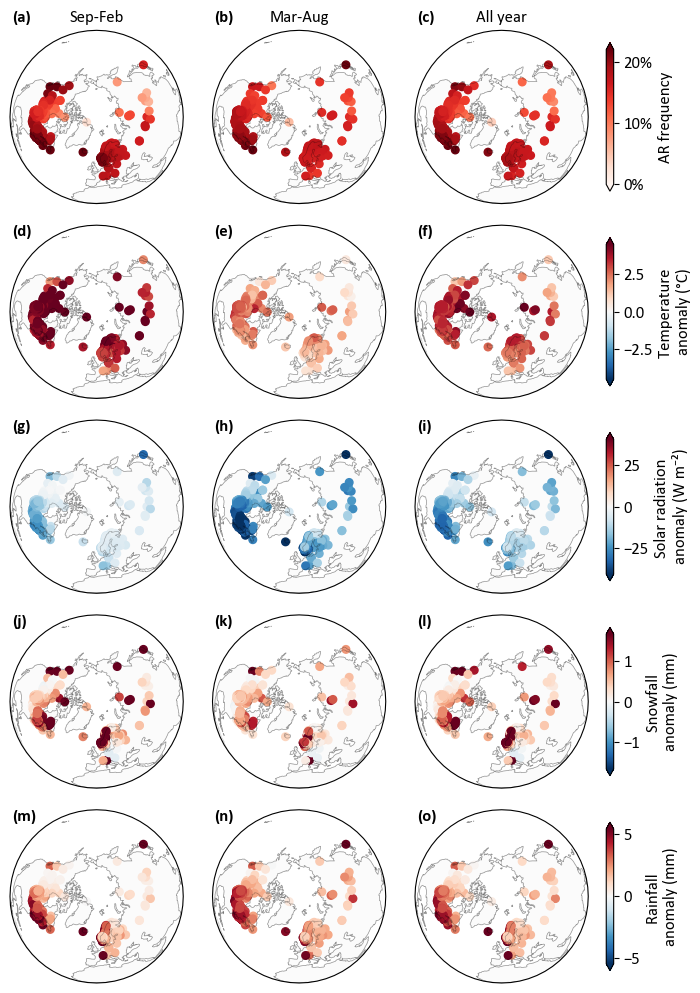

In [5]:
# Draw Figure 1

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

proj = ccrs.Orthographic(0, 90)
mpl.rcParams.update({'font.size': 12, 'font.sans-serif': 'Calibri'})
fig, axs = plt.subplots(nrows=5, ncols=3, figsize=(7, 10), subplot_kw={'projection': proj}, gridspec_kw={"width_ratios" : [1, 1, 1]},)
axes = axs.ravel()

for ii in range(15):
    axes[ii].add_feature(cfeature.LAND, facecolor='whitesmoke', edgecolor='grey', linewidth=0.5, alpha=0.3)
    axes[ii].add_feature(cfeature.COASTLINE, linewidth=0.5, alpha=0.3)
    axes[ii].set_global()
    if ii < 3:
        axes[ii].text(0.01, 1.11, '(%s)' % string.ascii_lowercase[ii], transform=axes[ii].transAxes, ha='left', va='top', fontweight='bold')
    else:
        axes[ii].text(0.01, 1, '(%s)' % string.ascii_lowercase[ii], transform=axes[ii].transAxes, ha='left', va='top', fontweight='bold')

ss = 30

# AR frequency
sc0 = axes[0].scatter(df.lon, df.lat, s=ss, transform=ccrs.PlateCarree(), cmap='Reds', c=df['freq_Sep-Feb']/181, vmin=0, vmax=0.22)
axes[0].set_title('Sep-Feb', fontsize=12)

sc1 = axes[1].scatter(df.lon, df.lat, s=ss, transform=ccrs.PlateCarree(), cmap='Reds', c=df['freq_Mar-Aug']/184, vmin=0, vmax=0.22)
axes[1].set_title('Mar-Aug', fontsize=12)

cb0 = plt.colorbar(sc0, ax=axes[0], orientation='vertical', extend='both', pad=0.08, shrink=0.8, aspect=20)
cb0.ax.set_visible(False)
cb1 = plt.colorbar(sc1, ax=axes[1], orientation='vertical', extend='both', pad=0.08, shrink=0.8, aspect=20)
cb1.ax.set_visible(False)

sc2 = axes[2].scatter(df.lon, df.lat, s=ss, transform=ccrs.PlateCarree(), cmap='Reds', c=df['freq_All year']/365, vmin=0, vmax=0.22)
cbar = plt.colorbar(sc2, ax=axes[2], orientation='vertical', extend='both', pad=0.08, shrink=0.8, aspect=20, label='AR frequency')
cbar.ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
axes[2].set_title('All year', fontsize=12)


# vars
for var, ii in zip(vars, [3, 6, 9, 12]):
    vmax = np.abs(df[[var + '_Sep-Feb', var + '_Mar-Aug', var + '_All year']]).quantile(0.90).max()
    sc3 = axes[ii].scatter(df.lon, df.lat, s=ss, transform=ccrs.PlateCarree(), cmap='RdBu_r', c=df[var + '_Sep-Feb'], vmin=-vmax, vmax=vmax)

    sc4 = axes[ii+1].scatter(df.lon, df.lat, s=ss, transform=ccrs.PlateCarree(), cmap='RdBu_r', c=df[var + '_Mar-Aug'], vmin=-vmax, vmax=vmax)
    
    cb3 = plt.colorbar(sc3, ax=axes[ii], orientation='vertical', extend='both', pad=0.08, shrink=0.8, aspect=20)
    cb3.ax.set_visible(False)
    cb4 = plt.colorbar(sc4, ax=axes[ii+1], orientation='vertical', extend='both', pad=0.08, shrink=0.8, aspect=20)
    cb4.ax.set_visible(False)

    sc5 = axes[ii+2].scatter(df.lon, df.lat, s=ss, transform=ccrs.PlateCarree(), cmap='RdBu_r', c=df[var + '_All year'], vmin=-vmax, vmax=vmax)
    plt.colorbar(sc5, ax=axes[ii+2], orientation='vertical', extend='both', pad=0.08, shrink=0.8, aspect=20, label=var_names[var])


fig.subplots_adjust(bottom=0.01, top=0.975, left=0.02, right=0.92, wspace=-0.1, hspace=0.05)
plt.show()

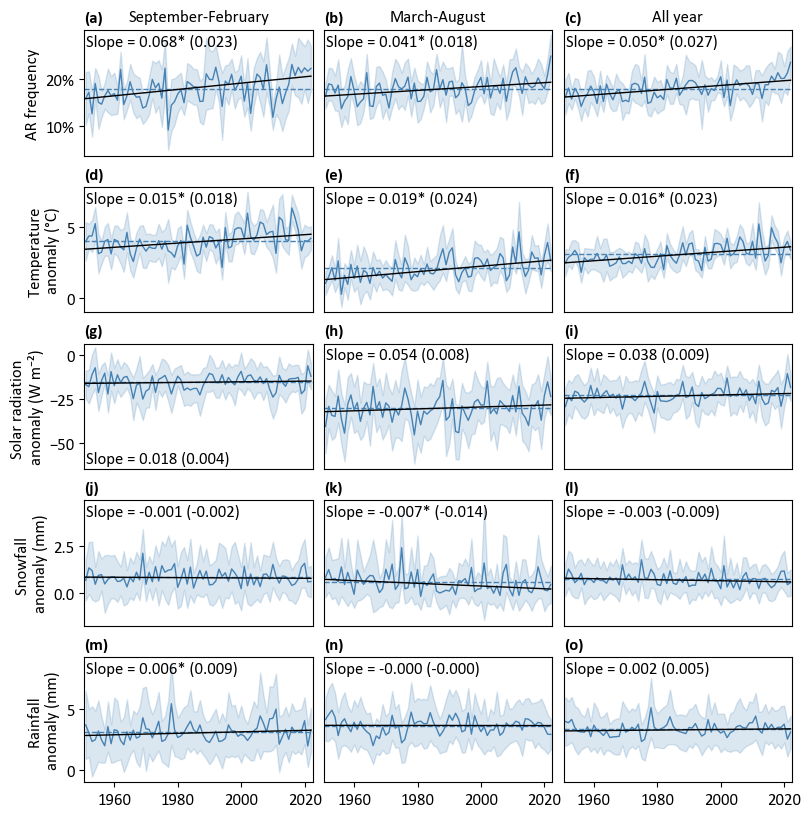

In [6]:
# Draw Figure S3

import pymannkendall as mk

mpl.rcParams.update({'font.size': 12, 'font.sans-serif': 'Calibri'})
fig, axs = plt.subplots(nrows=5, ncols=3, figsize=(8, 8), )
axes = axs.ravel()

def draw_fill(ax, data, tt=0):
    x = data.index
    y = data.mean(axis=1)
    y_mean = np.mean(y)
    ax.axhline(y_mean, color="steelblue", ls="--", lw=1)
    
    ax.plot(x, y, lw=1, color='steelblue')
    
    std_series2 = data.std(axis=1)
    upper2 = y + std_series2
    lower2 = y - std_series2
    ax.fill_between(x, lower2, upper2, color='steelblue', alpha=0.2, zorder=1)
    
    result = mk.trend_free_pre_whitening_modification_test(y)
    slope = result.slope
    intercept = np.median(y - slope * x)
    trend_line = slope * x + intercept
    p = result.p

    normalized_result = mk.trend_free_pre_whitening_modification_test((y - np.mean(y)) / np.std(y))
    normalized_slope = normalized_result.slope

    if p < 0.05:
        stars = "*"
    else:
        stars = ""
    
    ax.plot(x, trend_line, 'k-', lw=1, label=f"Sen's slope={slope:.3f} ({normalized_slope:.3f})")
    if tt == 0:
        ax.text(0.01, 0.97, f"Slope = {slope:.3f}{stars} ({normalized_slope:.3f})", va='top', ha='left', transform=ax.transAxes)
    elif tt == 1:
        ax.text(0.01, 0.02, f"Slope = {slope:.3f}{stars} ({normalized_slope:.3f})", va='bottom', ha='left', transform=ax.transAxes)
    
    ax.set_xlim((x.min()-0.5, x.max()+0.5))
    
    return

for ii, var in enumerate(['freq', 't2m', 'ssr', 'sf', 'rf']):
    for jj, ss in enumerate(['AutWin', 'SprSum', 'ALLYear', ]):
        if var == 'freq':
            data = pd.read_csv(root / f'AR_frequency_annual_{ss}.csv', index_col=0)
            if ss == 'AutWin':
                data = data/181*100
            elif ss == 'SprSum':
                data = data/184*100
            elif ss == 'ALLYear':
                data = data/365*100
        else:
            data = pd.read_csv(root / f'AR_related_{var}_anom_{ss}.csv', index_col=0)
        
        index = ii*3+jj
        if index in [6]:
            draw_fill(axs[ii, jj], data, tt=1)
        else:
            draw_fill(axs[ii, jj], data)
    ymin = np.min([axs[ii, 0].get_ylim()[0], axs[ii, 1].get_ylim()[0],  axs[ii, 2].get_ylim()[0]])
    ymax = np.max([axs[ii, 0].get_ylim()[1], axs[ii, 1].get_ylim()[1],  axs[ii, 2].get_ylim()[1]])
    axs[ii, 0].set_ylim([ymin, ymax])
    axs[ii, 1].set_ylim([ymin, ymax])
    axs[ii, 2].set_ylim([ymin, ymax])
    axs[ii, 1].set_yticks([])
    axs[ii, 2].set_yticks([])


for ii in range(3*4):
    axes[ii].set_xticks([])

for ii in range(3*5):
    axes[ii].set_title('(%s)' % string.ascii_lowercase[ii], fontsize=12, fontweight='bold', loc='left')

axes[0].text(0.5, 1.05, 'September-February', transform=axes[0].transAxes, ha='center', va='bottom')
axes[1].text(0.5, 1.05, 'March-August', transform=axes[1].transAxes, ha='center', va='bottom')
axes[2].text(0.5, 1.05, 'All year', transform=axes[2].transAxes, ha='center', va='bottom')

axes[0].set_yticks([10, 20], ['10%', '20%'])

var_names = {'freq': 'AR frequency',
             't2m': 'Temperature \nanomaly (°C)', 
             'sf':'Snowfall \nanomaly (mm)', 
             'rf':'Rainfall \nanomaly (mm)', 
             'ssr': 'Solar radiation \nanomaly (W m⁻²)'}

for ii, var in enumerate(['freq', 't2m', 'ssr', 'sf', 'rf']):
    axs[ii, 0].set_ylabel(var_names[var])

fig.subplots_adjust(bottom=0.03, top=0.97, left=0.1, right=0.985, wspace=0.05, hspace=0.25)
plt.show()